## Credit Card Customer Churn Analysis

<h3>Kevin Alexis Sotelo Guzmán</h3>

<h3>10/07/2026</h3>

<h3>Python</h3>


# 1. Ask

- Background:

The Credit Card Customers dataset contains demographic, financial, and behavioral information for more than 10,000 credit card customers from a banking institution. Its purpose is to analyze the factors associated with customer churn and support the development of analytical models to identify customers who are most likely to discontinue using the service. The dataset includes variables such as age, income, education level, card type, credit limit, transaction activity, and customer status.

- Business Problem:

The banking institution seeks to understand why some customers stop using their credit cards. Identifying the factors that influence customer churn will help implement more effective retention strategies, improve customer satisfaction, and reduce the financial losses associated with customer attrition.

- General Objective:

Analyze the behavior of credit card customers to identify the factors associated with customer churn and develop strategic recommendations to improve customer retention.

- Specific Objectives:

1. Analyze the demographic and financial characteristics of customers.
2. Identify the differences between active customers and those who have churned.
3. Classify customers according to their usage patterns and financial behavior.
4. Develop business recommendations aimed at reducing the customer churn rate.

- Business Questions:

1. What are the characteristics of customers who discontinue using their credit cards?
2. Which variables are most strongly associated with customer churn?
3. Which customer segments are at the highest risk of churning?
4. What strategies can be implemented to improve customer retention based on the findings of the analysis?

# 2. Prepare

- Dataset:

The data source used for this case study is the Credit Card Customers dataset. This dataset is hosted on Kaggle and was shared by Sakshi Goyal. It contains information about credit card customers from a banking institution, including demographic, financial, and behavioral characteristics.

- Data Accessibility and Privacy:

The dataset is publicly available on Kaggle for educational and research purposes. The information has been anonymized, meaning it does not contain any personally identifiable information that could be used to identify individual customers. This allows the dataset to be used for data analysis and model development without compromising customer privacy.

- Data Organization and Verification:

The dataset consists of a single CSV file named BankChurners.csv.

The file contains a wide range of information related to credit card customers, including:

Demographic information

Income and education level

Marital status

Credit card type and category

Length of relationship with the bank

Credit limit, outstanding balance, and available credit

Number and amount of transactions

Credit utilization ratio

Customer status (existing customer or churned customer)

Each record represents an individual customer, and each column corresponds to a specific characteristic used to analyze customer behavior and the likelihood of customer churn.

- Data Limitations:

This dataset has several limitations that may affect the results of the analysis. The main limitations include:

The name of the financial institution from which the data was collected is not disclosed.

The exact time period during which the data was collected is not provided.

The data is fully anonymized, making it impossible to identify individual customers or enrich the analysis with external information.

These limitations should be considered when interpreting the results and developing the conclusions and business recommendations derived from the analysis.

# 3. Process

Herramientas: Python, pandas, numpy

Loading Libraries and Importing the Dataset:

In [1]:

import os
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))


import kagglehub


/kaggle/input/datasets/sakshigoyal7/credit-card-customers/BankChurners.csv


First, I imported the `BankChurners.csv` dataset using the `pd.read_csv()` function from the pandas library.



In [2]:
# prepare the data

df = pd.read_csv('/kaggle/input/datasets/sakshigoyal7/credit-card-customers/BankChurners.csv')

Once the dataset was loaded, I checked the number of rows and columns it contains using pandas' `.shape` attribute.


In [3]:
df.shape

(10127, 23)

The dataset contains 10,127 rows and 23 columns. Next, I examined the column names using pandas' `.columns` attribute.


In [4]:
df.columns

Index(['CLIENTNUM', 'Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1',
       'Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2'],
      dtype='object')

In [5]:
df.head(20)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1,Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,12691.0,777,11914.0,1.335,1144,42,1.625,0.061,0.000093,0.99991
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,8256.0,864,7392.0,1.541,1291,33,3.714,0.105,0.000057,0.99994
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,3418.0,0,3418.0,2.594,1887,20,2.333,0.000,0.000021,0.99998
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,3313.0,2517,796.0,1.405,1171,20,2.333,0.760,0.000134,0.99987
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,4716.0,0,4716.0,2.175,816,28,2.500,0.000,0.000022,0.99998
5,713061558,Existing Customer,44,M,2,Graduate,Married,$40K - $60K,Blue,36,...,4010.0,1247,2763.0,1.376,1088,24,0.846,0.311,0.000055,0.99994
6,810347208,Existing Customer,51,M,4,Unknown,Married,$120K +,Gold,46,...,34516.0,2264,32252.0,1.975,1330,31,0.722,0.066,0.000123,0.99988
7,818906208,Existing Customer,32,M,0,High School,Unknown,$60K - $80K,Silver,27,...,29081.0,1396,27685.0,2.204,1538,36,0.714,0.048,0.000086,0.99991
8,710930508,Existing Customer,37,M,3,Uneducated,Single,$60K - $80K,Blue,36,...,22352.0,2517,19835.0,3.355,1350,24,1.182,0.113,0.000045,0.99996
9,719661558,Existing Customer,48,M,2,Graduate,Single,$80K - $120K,Blue,36,...,11656.0,1677,9979.0,1.524,1441,32,0.882,0.144,0.000303,0.99970


The dataset contains demographic, financial, and behavioral information about credit card customers. Based on an initial review, the columns can be summarized as follows:

- CLIENTNUM: Unique identifier assigned to each customer.
- Attrition_Flag: Customer status, indicating whether the customer is still active (Existing Customer) or has discontinued the service (Attrited Customer).
- Customer_Age: Customer's age.
- Gender: Customer's gender.
- Dependent_count: Number of the customer's financial dependents.
- Education_Level: Customer's highest level of education.
- Marital_Status: Customer's marital status.
- Income_Category: Customer's annual income category.
- Card_Category: Credit card category (Blue, Silver, Gold, or Platinum).
- Months_on_book: Number of months the customer has maintained a relationship with the bank.
- Total_Relationship_Count: Total number of financial products the customer has with the bank.
- Months_Inactive_12_mon: Number of months the customer was inactive during the last 12 months.
- Contacts_Count_12_mon: Number of contacts between the customer and the bank during the last 12 months.
- Credit_Limit: Customer's assigned credit limit.
- Total_Revolving_Bal: Outstanding revolving balance on the customer's credit card.
- Avg_Open_To_Buy: Average amount of available credit.
- Total_Amt_Chng_Q4_Q1: Change in the total transaction amount between the fourth and first quarters.
- Total_Trans_Amt: Total transaction amount during the last 12 months.
- Total_Trans_Ct: Total number of transactions during the last 12 months.
- Total_Ct_Chng_Q4_Q1: Change in the total number of transactions between the fourth and first quarters.
- Avg_Utilization_Ratio: Average credit utilization ratio.
- Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1: Probability generated by a Naive Bayes classification model to predict customer status. This variable was created for modeling purposes and does not represent an actual customer characteristic.
- Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2: A second probability generated by the Naive Bayes model as a complement to the previous variable.

After reviewing the columns and understanding the information contained in the dataset, we can begin the data cleaning process.

**Data cleaning**

The first step in the data cleaning process is to verify that the data types of each column are consistent with the content and purpose of the information they store. To do this, we will use pandas .dtypes attribute, which allows us to identify the data type associated with each column.


In [6]:
df.dtypes

CLIENTNUM                                                                                                                               int64
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income

We can observe that the CLIENTNUM column is stored as an integer (int). However, in this case, it is more appropriate to treat it as a string (string or object), since it serves only as a unique identifier for each customer and is not intended for mathematical operations such as addition, subtraction, or multiplication.

On the other hand, columns such as Attrition_Flag, Gender, Education_Level, Marital_Status, Income_Category, and Card_Category are stored as the object data type, which is appropriate because they represent categorical values rather than numerical measurements.

Similarly, numerical variables such as Customer_Age, Dependent_count, Months_on_book, and Total_Relationship_Count are stored as numeric data types (int or float), making them suitable for calculations and statistical analysis.

Overall, aside from the recommended conversion of the CLIENTNUM column, the remaining columns have appropriate data types for the information they contain.

In [7]:
# clean the data

df['CLIENTNUM'] = df['CLIENTNUM'].astype(str)
df.dtypes


CLIENTNUM                                                                                                                              object
Attrition_Flag                                                                                                                         object
Customer_Age                                                                                                                            int64
Gender                                                                                                                                 object
Dependent_count                                                                                                                         int64
Education_Level                                                                                                                        object
Marital_Status                                                                                                                         object
Income

I corrected the previously identified data type by converting the CLIENTNUM column from int to str using the .astype(str) function. This change was made because the column serves only as a unique identifier for each customer and is not intended for mathematical operations.

Reviewing Column Values

After correcting the data type, I evaluated which columns were truly relevant to the analysis. In particular, I focused on the last two variables in the dataset:

Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1
Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2

These columns contain the probabilities generated by a Naive Bayes classification model used to predict customer status. However, they do not represent actual customer characteristics but rather the output of a predictive model. Therefore, they do not provide meaningful information for exploratory data analysis and could introduce bias into the analysis if retained.

Checking for Missing and Null Values:


In [8]:
 # checking null values
df.isna().sum()

CLIENTNUM                                                                                                                             0
Attrition_Flag                                                                                                                        0
Customer_Age                                                                                                                          0
Gender                                                                                                                                0
Dependent_count                                                                                                                       0
Education_Level                                                                                                                       0
Marital_Status                                                                                                                        0
Income_Category                                 

In [9]:
# checking duplicates
df.duplicated().sum()

np.int64(0)

The dataset contains no missing values and no duplicate records.


Selecting a Subset of the Dataset:


In [10]:
# subset the data
df = df[['CLIENTNUM','Attrition_Flag', 'Customer_Age', 'Gender',
       'Dependent_count', 'Education_Level', 'Marital_Status',
       'Income_Category', 'Card_Category', 'Months_on_book',
       'Total_Relationship_Count', 'Months_Inactive_12_mon',
       'Contacts_Count_12_mon', 'Credit_Limit', 'Total_Revolving_Bal',
       'Avg_Open_To_Buy', 'Total_Amt_Chng_Q4_Q1', 'Total_Trans_Amt',
       'Total_Trans_Ct', 'Total_Ct_Chng_Q4_Q1', 'Avg_Utilization_Ratio']].copy()

I excluded the following columns from the subset of data used for the analysis:

Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_1

Naive_Bayes_Classifier_Attrition_Flag_Card_Category_Contacts_Count_12_mon_Dependent_count_Education_Level_Months_Inactive_12_mon_2

These two columns contain the probabilities generated by a Naive Bayes machine learning model. They do not represent actual customer data but rather the output of a predictive model designed to classify the Attrition_Flag variable. Including them in the exploratory data analysis could introduce data leakage and bias the results, so they were removed from the dataset used for this analysis.

In [11]:
df.head(5)

,CLIENTNUM,Attrition_Flag,Customer_Age,Gender,Dependent_count,Education_Level,Marital_Status,Income_Category,Card_Category,Months_on_book,...,Months_Inactive_12_mon,Contacts_Count_12_mon,Credit_Limit,Total_Revolving_Bal,Avg_Open_To_Buy,Total_Amt_Chng_Q4_Q1,Total_Trans_Amt,Total_Trans_Ct,Total_Ct_Chng_Q4_Q1,Avg_Utilization_Ratio
0,768805383,Existing Customer,45,M,3,High School,Married,$60K - $80K,Blue,39,...,1,3,12691.0,777,11914.0,1.335,1144,42,1.625,0.061
1,818770008,Existing Customer,49,F,5,Graduate,Single,Less than $40K,Blue,44,...,1,2,8256.0,864,7392.0,1.541,1291,33,3.714,0.105
2,713982108,Existing Customer,51,M,3,Graduate,Married,$80K - $120K,Blue,36,...,1,0,3418.0,0,3418.0,2.594,1887,20,2.333,0.000
3,769911858,Existing Customer,40,F,4,High School,Unknown,Less than $40K,Blue,34,...,4,1,3313.0,2517,796.0,1.405,1171,20,2.333,0.760
4,709106358,Existing Customer,40,M,3,Uneducated,Married,$60K - $80K,Blue,21,...,1,0,4716.0,0,4716.0,2.175,816,28,2.500,0.000


# 4. Analyze

1 . What Are the Characteristics of Customers Who Churn from the Credit Card Service?


Demographic variables:

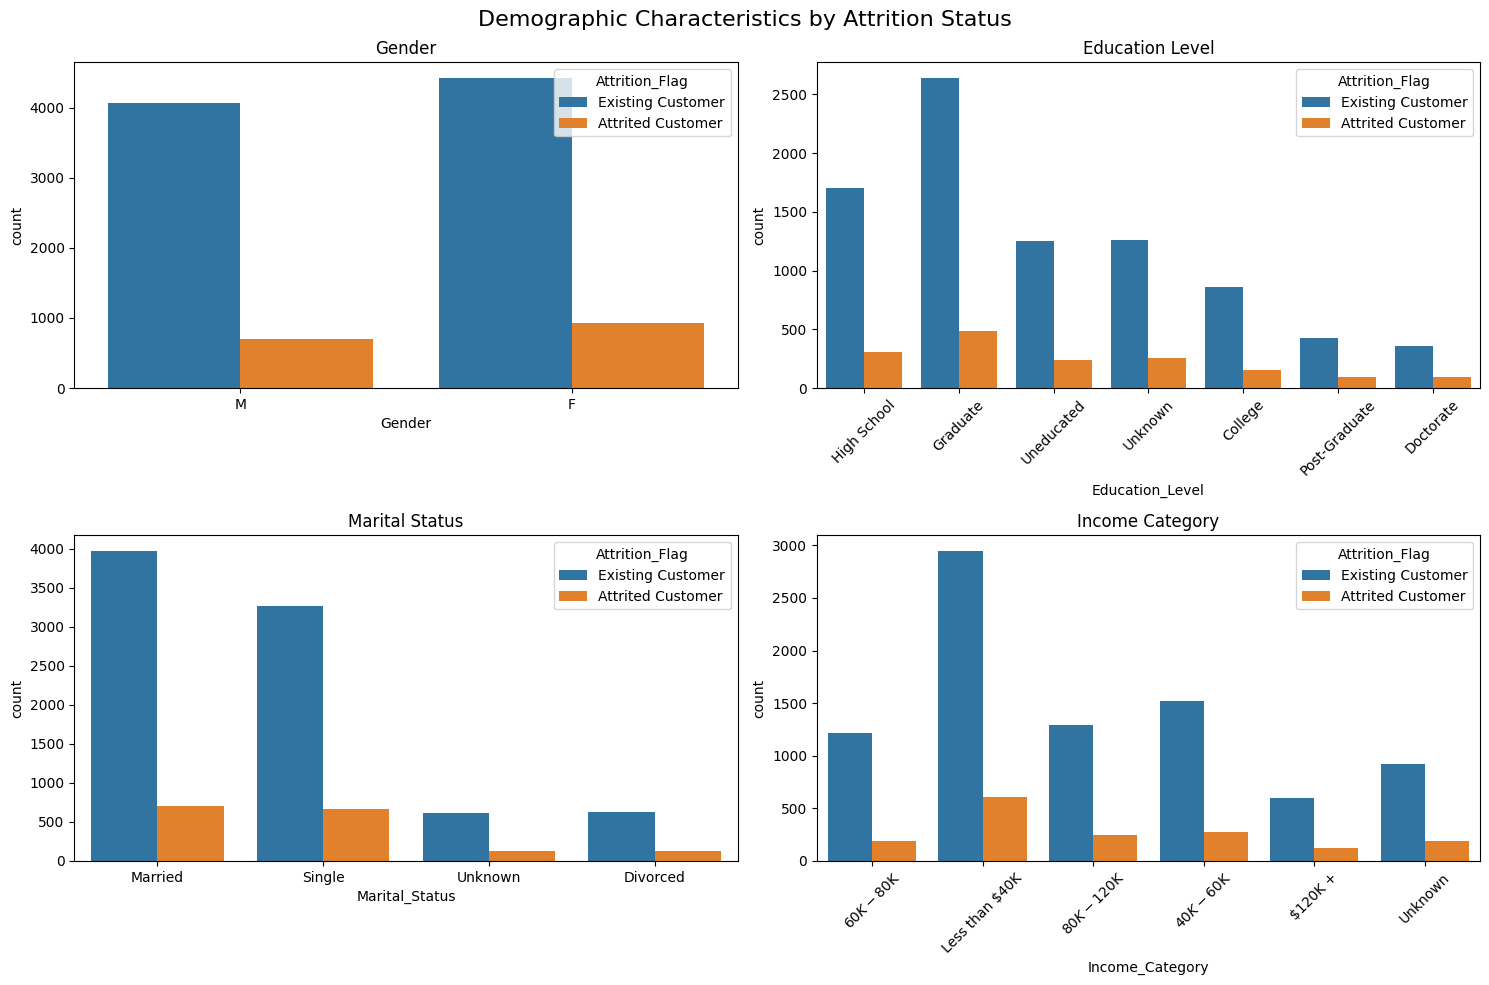

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=df, x='Gender', hue='Attrition_Flag', ax=axes[0,0])
axes[0,0].set_title('Gender')

sns.countplot(data=df, x='Education_Level', hue='Attrition_Flag', ax=axes[0,1])
axes[0,1].set_title('Education Level')
axes[0,1].tick_params(axis='x', rotation=45)

sns.countplot(data=df, x='Marital_Status', hue='Attrition_Flag', ax=axes[1,0])
axes[1,0].set_title('Marital Status')

sns.countplot(data=df, x='Income_Category', hue='Attrition_Flag', ax=axes[1,1])
axes[1,1].set_title('Income Category')
axes[1,1].tick_params(axis='x', rotation=45)

plt.suptitle('Demographic Characteristics by Attrition Status', fontsize=16)

plt.tight_layout()

plt.show()

Overall, the demographic variables analyzed—including gender, education level, marital status, and income category—show similar distributions between active customers and those who churned. Although some groups account for a larger number of churned customers, this is largely because they also represent the largest proportion of customers in the dataset. Therefore, these charts do not reveal sufficiently strong differences to suggest that demographic characteristics alone are the primary factors associated with customer churn.

These findings indicate that credit card usage and customer behavioral variables are likely to have greater explanatory power in understanding churn, which is explored in the following sections of the analysis.


Financial Variables:


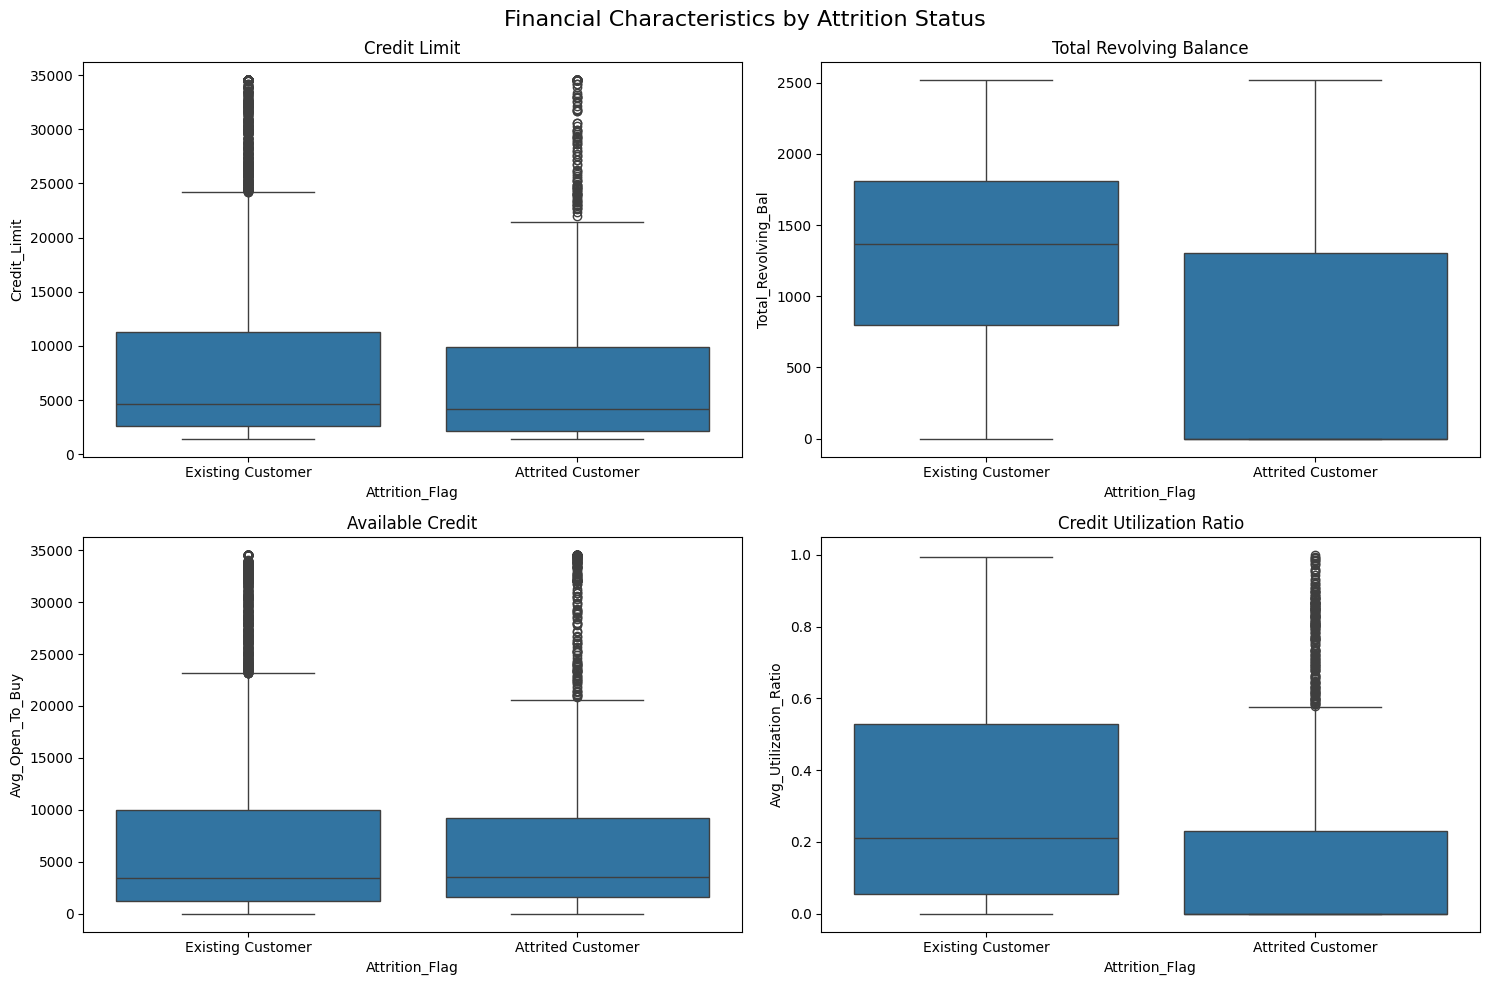

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.boxplot(data=df, x='Attrition_Flag', y='Credit_Limit', ax=axes[0,0])
axes[0,0].set_title('Credit Limit')

sns.boxplot(data=df, x='Attrition_Flag', y='Total_Revolving_Bal', ax=axes[0,1])
axes[0,1].set_title('Total Revolving Balance')

sns.boxplot(data=df, x='Attrition_Flag', y='Avg_Open_To_Buy', ax=axes[1,0])
axes[1,0].set_title('Available Credit')

sns.boxplot(data=df, x='Attrition_Flag', y='Avg_Utilization_Ratio', ax=axes[1,1])
axes[1,1].set_title('Credit Utilization Ratio')

plt.suptitle('Financial Characteristics by Attrition Status', fontsize=16)

plt.tight_layout()

plt.show()

Overall, the results show that variables related to credit usage exhibit clearer differences than those associated with credit capacity. While credit limit and available credit display similar distributions between active and churned customers, revolving balance and credit utilization ratio reveal more pronounced differences.

In particular, customers who churned tend to maintain lower revolving balances and lower credit utilization ratios, suggesting that they used their credit cards less frequently before canceling the service. These findings indicate that the level of credit card usage may be a more relevant indicator of churn risk than the amount of credit granted by the financial institution.


Behavioral variables:

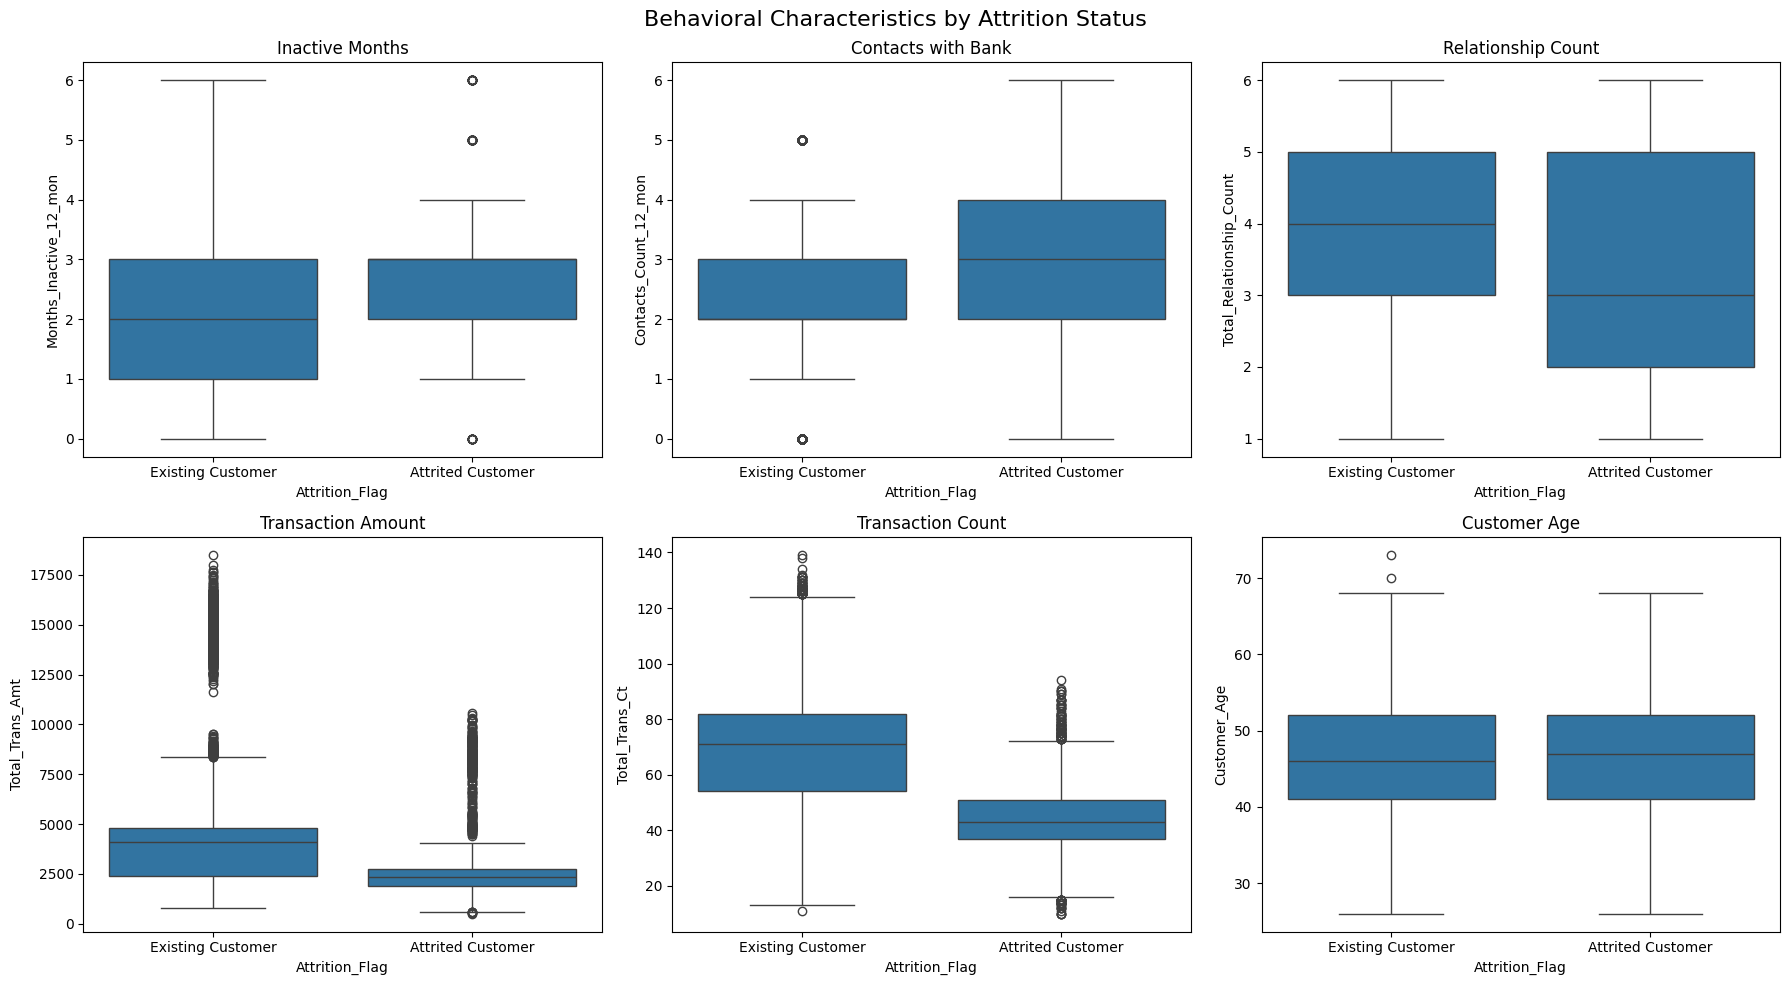

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Months_Inactive_12_mon',
            ax=axes[0,0])
axes[0,0].set_title('Inactive Months')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Contacts_Count_12_mon',
            ax=axes[0,1])
axes[0,1].set_title('Contacts with Bank')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Total_Relationship_Count',
            ax=axes[0,2])
axes[0,2].set_title('Relationship Count')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Amt',
            ax=axes[1,0])
axes[1,0].set_title('Transaction Amount')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Ct',
            ax=axes[1,1])
axes[1,1].set_title('Transaction Count')

sns.boxplot(data=df,
            x='Attrition_Flag',
            y='Customer_Age',
            ax=axes[1,2])
axes[1,2].set_title('Customer Age')

plt.suptitle('Behavioral Characteristics by Attrition Status', fontsize=16)

plt.tight_layout()

plt.show()

Overall, the results show that behavioral variables exhibit the most significant differences between active customers and those who churned. In particular, the number of transactions, total transaction amount, months of inactivity, and the number of financial products held are the variables most strongly associated with customer churn.

These findings suggest that credit card usage patterns and the customer's overall relationship with the bank are much more relevant in explaining churn than demographic characteristics. Consequently, the financial institution could leverage these behavioral variables to identify customers at higher risk of churning at an early stage and implement more effective retention strategies.


2 . What Variables Are Most Strongly Associated with Customer Churn?

Comparison of Behavioral Variables

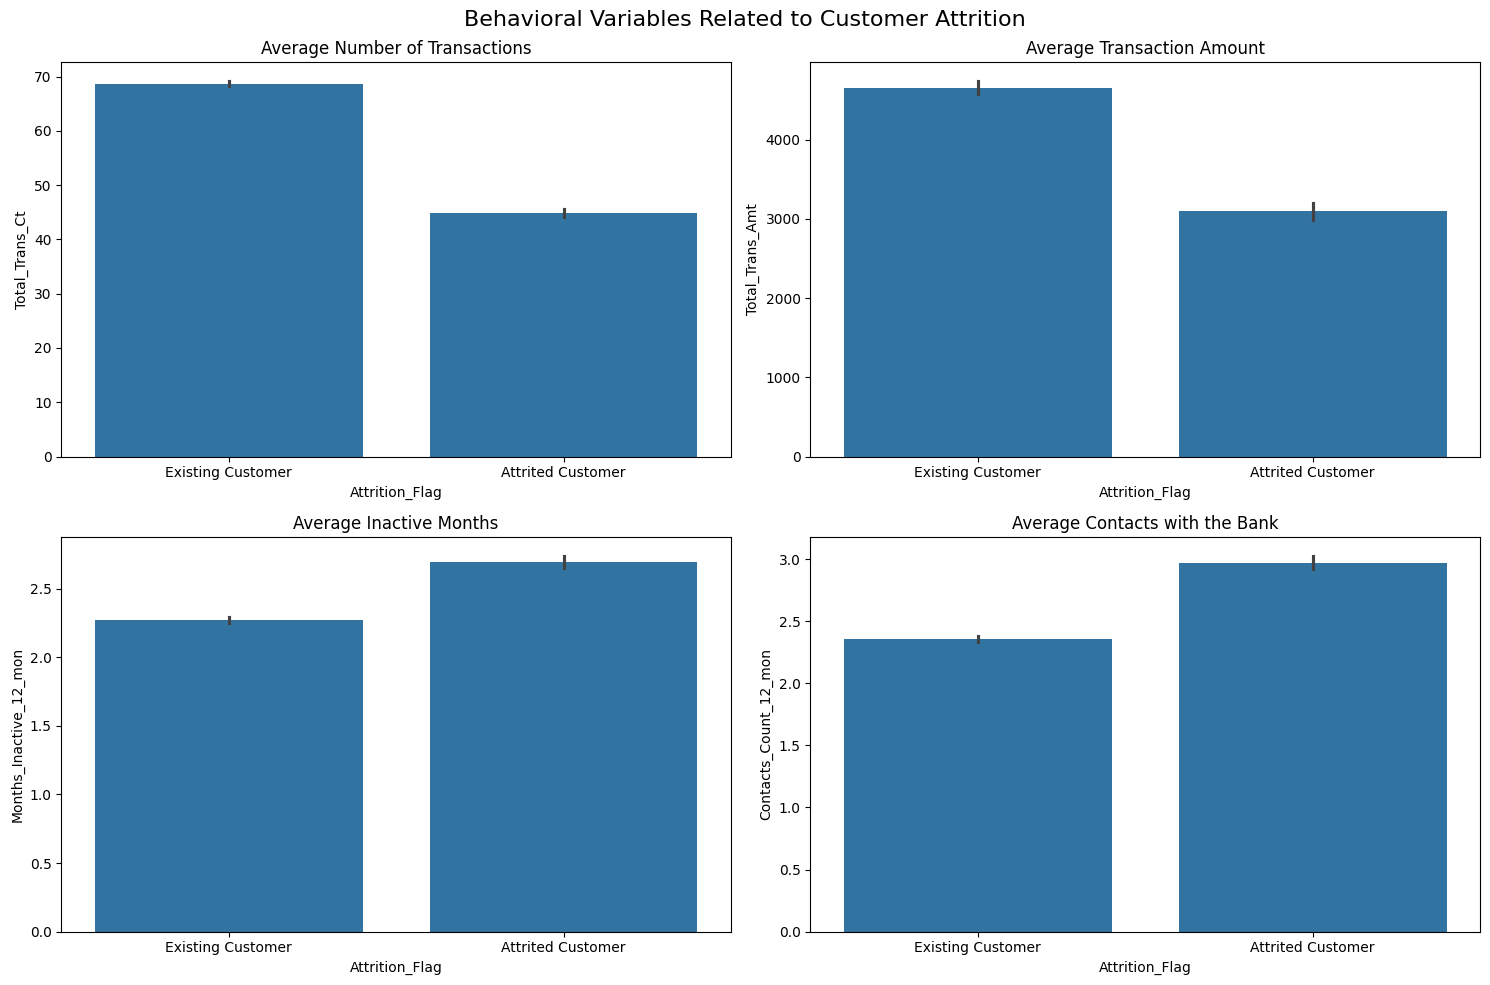

In [15]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Ct',
            ax=axes[0,0])

axes[0,0].set_title('Average Number of Transactions')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Trans_Amt',
            ax=axes[0,1])

axes[0,1].set_title('Average Transaction Amount')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Months_Inactive_12_mon',
            ax=axes[1,0])

axes[1,0].set_title('Average Inactive Months')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Contacts_Count_12_mon',
            ax=axes[1,1])

axes[1,1].set_title('Average Contacts with the Bank')

plt.suptitle('Behavioral Variables Related to Customer Attrition', fontsize=16)

plt.tight_layout()

plt.show()

The results show that variables related to customer behavior exhibit clear differences between active customers and those who churned. In particular, the number of transactions and the total transaction amount are considerably lower among customers who left the service, while the number of months inactive and the number of contacts with the bank are higher.

These findings suggest that a decline in credit card usage and an increase in inactivity are early indicators of customer churn. Additionally, a higher number of contacts with the bank may reflect unresolved issues or unmet customer needs before the decision to cancel the service is made.


Comparison of Financial Variables:


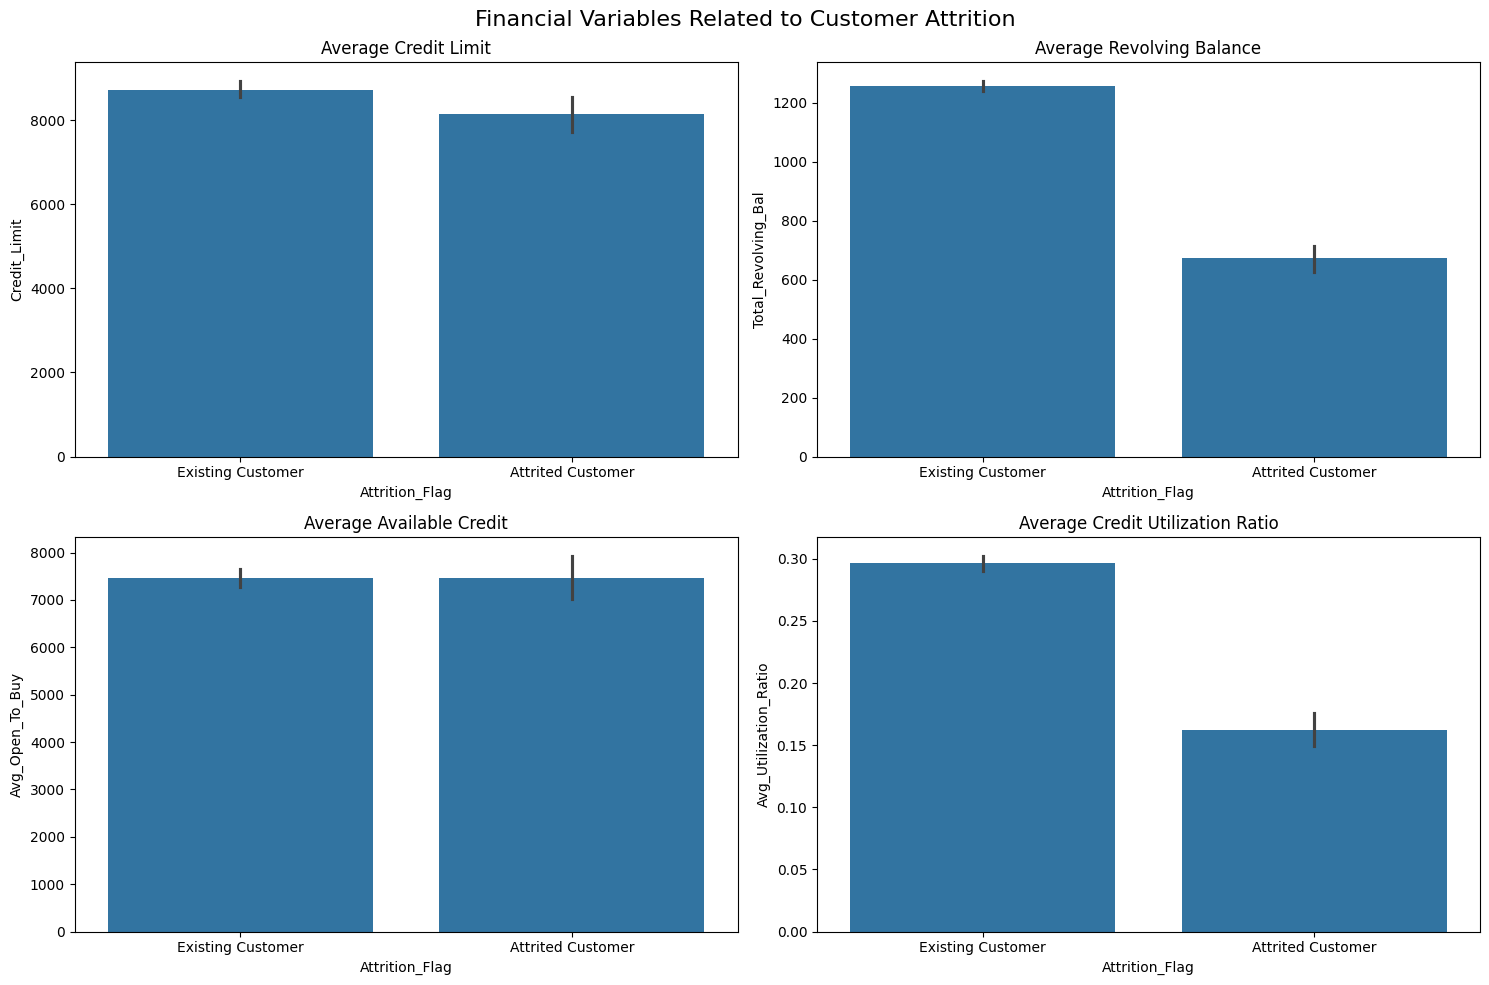

In [16]:
fig, axes = plt.subplots(2,2, figsize=(15,10))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Credit_Limit',
            ax=axes[0,0])

axes[0,0].set_title('Average Credit Limit')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Revolving_Bal',
            ax=axes[0,1])

axes[0,1].set_title('Average Revolving Balance')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Avg_Open_To_Buy',
            ax=axes[1,0])

axes[1,0].set_title('Average Available Credit')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Avg_Utilization_Ratio',
            ax=axes[1,1])

axes[1,1].set_title('Average Credit Utilization Ratio')

plt.suptitle('Financial Variables Related to Customer Attrition', fontsize=16)

plt.tight_layout()

plt.show()

Overall, the results show that variables related to the effective use of the credit line exhibit more significant differences than those associated with the customer's credit capacity.

While credit limit and available credit are very similar between active and churned customers, revolving balance and credit utilization ratio display much more pronounced differences.

These findings suggest that the level of credit card usage is more strongly associated with customer churn than the amount of credit authorized by the bank. In other words, customers who gradually stop using their available credit are more likely to discontinue the service.


Comparison of Customer–Bank Relationship Variables:


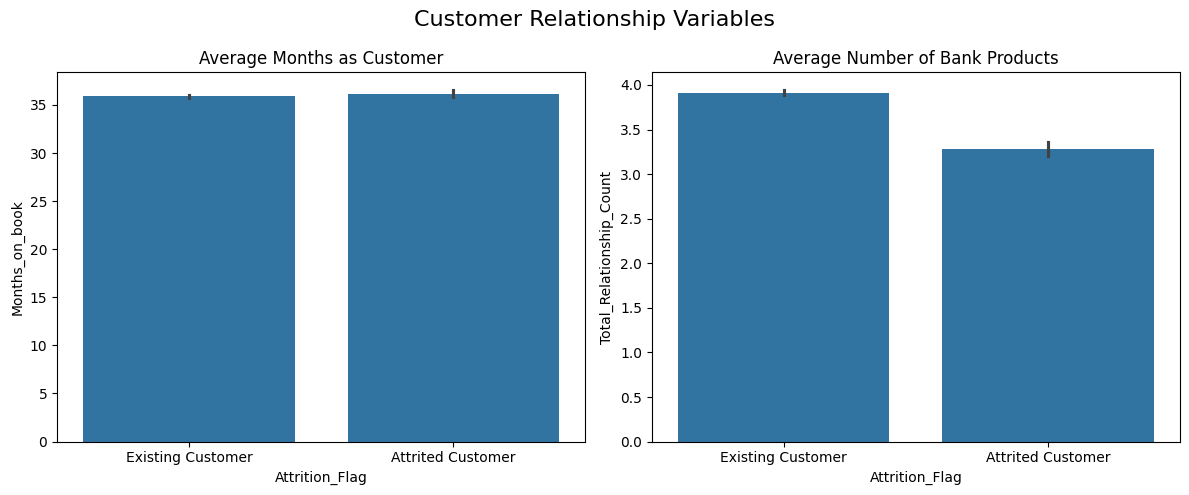

In [17]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Months_on_book',
            ax=axes[0])

axes[0].set_title('Average Months as Customer')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Relationship_Count',
            ax=axes[1])

axes[1].set_title('Average Number of Bank Products')

plt.suptitle('Customer Relationship Variables', fontsize=16)

plt.tight_layout()

plt.show()

The results indicate that customer tenure does not appear to be a significant factor in explaining churn, as both active and churned customers have a very similar average length of relationship with the bank.

In contrast, the number of financial products held shows a notable difference. Active customers tend to maintain a broader relationship with the financial institution by using more products, whereas churned customers generally hold fewer. This suggests that greater product diversification strengthens the customer–bank relationship and reduces the likelihood of customer churn.


Comparison of Credit Card Usage Variables:

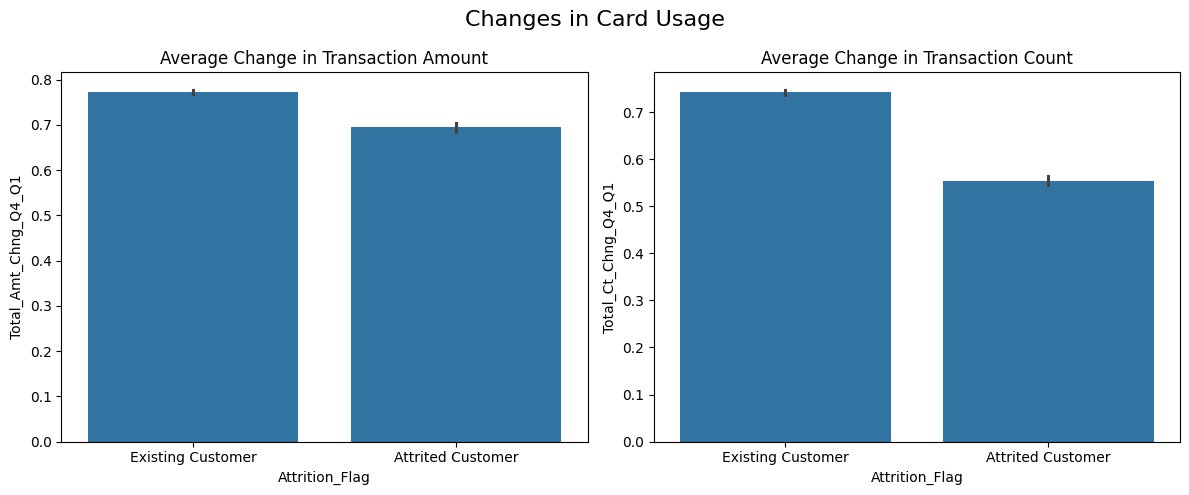

In [18]:
fig, axes = plt.subplots(1,2, figsize=(12,5))

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Amt_Chng_Q4_Q1',
            ax=axes[0])

axes[0].set_title('Average Change in Transaction Amount')

sns.barplot(data=df,
            x='Attrition_Flag',
            y='Total_Ct_Chng_Q4_Q1',
            ax=axes[1])

axes[1].set_title('Average Change in Transaction Count')

plt.suptitle('Changes in Card Usage', fontsize=16)

plt.tight_layout()

plt.show()

The results show that customers who churned experienced a more pronounced decline in both the total transaction amount and the number of transactions between the first and fourth quarters. This suggests that, before canceling their credit cards, these customers gradually reduce their level of card activity.

Additionally, the difference observed in the change in the number of transactions is greater than the difference in the change in the total transaction amount. This indicates that transaction frequency may be a more sensitive indicator of customer churn risk than transaction value.

3 . Which Customer Segments Are at the Highest Risk of Churn?


To identify the customer segments at the highest risk of churn, customers were grouped according to key characteristics of their behavior and relationship with the bank. Rather than relying solely on statistical criteria, the segments were defined using business-meaningful ranges, making the results easier to interpret and more useful for developing targeted customer retention strategies.

In [19]:
df[['Total_Trans_Ct',
    'Months_Inactive_12_mon',
    'Total_Relationship_Count',
    'Avg_Utilization_Ratio']].describe()

,Total_Trans_Ct,Months_Inactive_12_mon,Total_Relationship_Count,Avg_Utilization_Ratio
count,10127.000000,10127.000000,10127.000000,10127.000000
mean,64.858695,2.341167,3.812580,0.274894
std,23.472570,1.010622,1.554408,0.275691
min,10.000000,0.000000,1.000000,0.000000
25%,45.000000,2.000000,3.000000,0.023000
50%,67.000000,2.000000,4.000000,0.176000
75%,81.000000,3.000000,5.000000,0.503000
max,139.000000,6.000000,6.000000,0.999000


Segmentation by Credit Card Usage


In [20]:
df['Usage_Level'] = pd.cut(
    df['Total_Trans_Ct'],
    bins=[0,40,80,150],
    labels=['Low','Medium','High']
)

In [21]:
usage = pd.crosstab(
    df['Usage_Level'],
    df['Attrition_Flag'],
    normalize='index'
)*100

usage

Attrition_Flag,Attrited Customer,Existing Customer
Usage_Level,,
Low,31.527348,68.472652
Medium,17.467636,82.532364
High,1.215686,98.784314


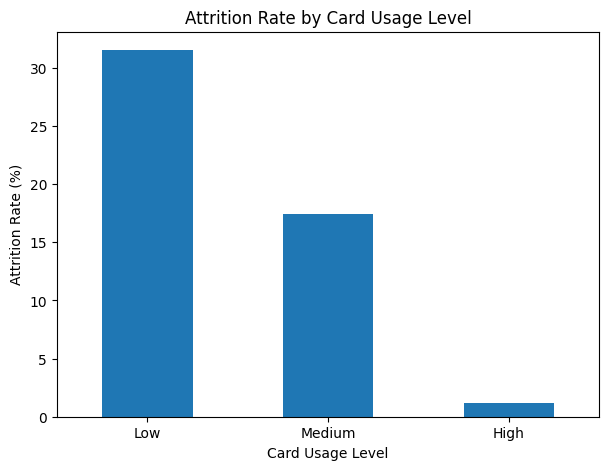

In [22]:
usage['Attrited Customer'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Attrition Rate by Card Usage Level')
plt.xlabel('Card Usage Level')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

The results suggest that the level of credit card usage is one of the factors most strongly associated with customer churn. Customers who use their credit cards infrequently are significantly more likely to leave the service, whereas those who make a higher number of transactions tend to remain active customers.

This pattern reinforces the findings from the previous analyses, which showed that customers who churned made fewer transactions and recorded lower total purchase amounts.


Months of Inactivity


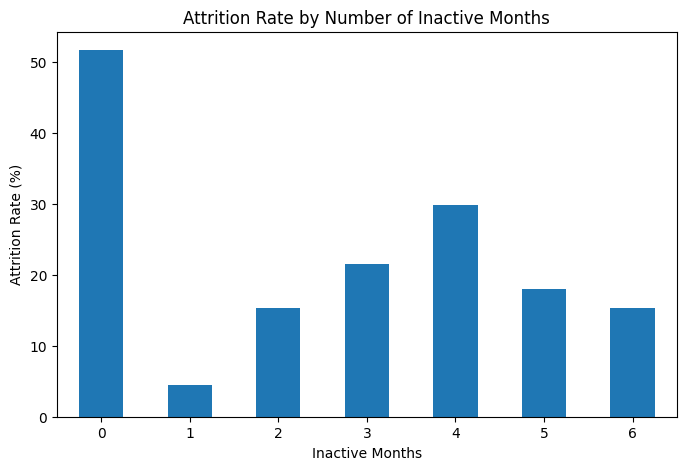

In [23]:
inactive = pd.crosstab(
    df['Months_Inactive_12_mon'],
    df['Attrition_Flag'],
    normalize='index'
) * 100

inactive['Attrited Customer'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition Rate by Number of Inactive Months')
plt.xlabel('Inactive Months')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

Although customers with 0 months of inactivity exhibit the highest churn rate, this segment consists of only 29 customers. Therefore, this percentage should be interpreted with caution. Due to the small sample size, a few churn cases have a substantial impact on the observed rate and do not necessarily reflect the overall behavior of the customer population.

Segmentation by Number of Financial Products


In [24]:
relationship = pd.crosstab(
    df['Total_Relationship_Count'],
    df['Attrition_Flag'],
    normalize='index'
)*100

relationship

Attrition_Flag,Attrited Customer,Existing Customer
Total_Relationship_Count,,
1,25.604396,74.395604
2,27.835881,72.164119
3,17.353579,82.646421
4,11.767782,88.232218
5,12.004231,87.995769
6,10.503751,89.496249


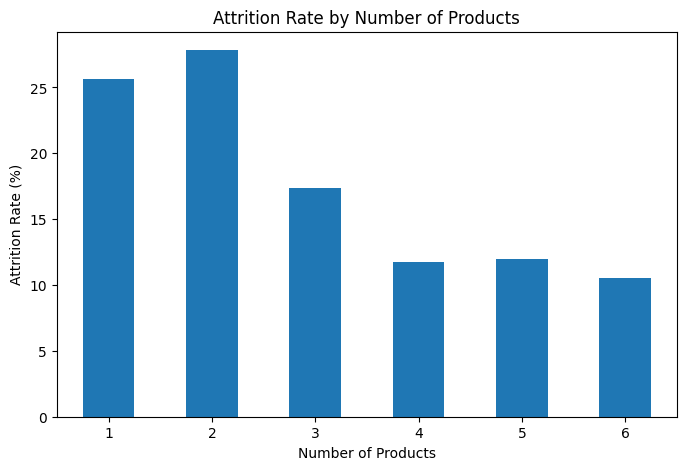

In [25]:
relationship['Attrited Customer'].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title('Attrition Rate by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

The results suggest that the strength of a customer's relationship with the bank is an important factor associated with churn. Customers who hold only one or two financial products are significantly more likely to cancel the service, whereas those with a broader relationship with the institution tend to remain active customers.

This may be because customers with multiple financial products develop a stronger relationship with the bank, increasing the costs or difficulties of switching to another institution and, consequently, strengthening customer loyalty.


Segmentation by Credit Utilization Ratio


In [26]:
df['Utilization_Level'] = pd.cut(
    df['Avg_Utilization_Ratio'],
    bins=[0,0.30,0.70,1],
    labels=['Low','Medium','High'],
    include_lowest=True
)

In [27]:
utilization = pd.crosstab(
    df['Utilization_Level'],
    df['Attrition_Flag'],
    normalize='index'
)*100

utilization

Attrition_Flag,Attrited Customer,Existing Customer
Utilization_Level,,
Low,20.438190,79.561810
Medium,7.531083,92.468917
High,12.936733,87.063267


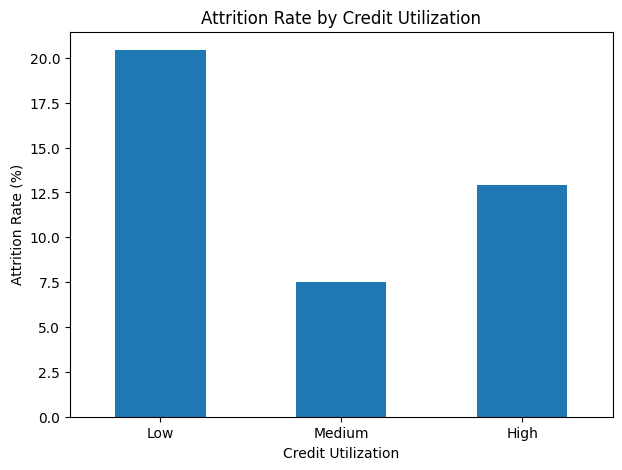

In [28]:
utilization['Attrited Customer'].plot(
    kind='bar',
    figsize=(7,5)
)

plt.title('Attrition Rate by Credit Utilization')
plt.xlabel('Credit Utilization')
plt.ylabel('Attrition Rate (%)')

plt.xticks(rotation=360)

plt.show()

The analysis suggests that credit utilization is associated with customer churn, although the relationship is not entirely linear. Customers with moderate credit utilization exhibit the highest retention rates, whereas those with very low credit utilization face the greatest risk of churning.

This pattern may indicate that customers who make little use of their available credit perceive less value in the product or have gradually reduced their card activity before deciding to cancel the service.


# 5. Share

After analyzing the demographic, financial, and behavioral characteristics of customers, as well as identifying the customer segments with the highest risk of churn, several patterns emerged that provide a better understanding of the factors associated with customer attrition. This section summarizes the key findings from the analysis and answers the business questions established at the beginning of the project.

1 . What Are the Characteristics of Customers Who Churn from the Credit Card Service?

* They use their credit cards less frequently.
* They spend lower amounts on purchases.
* They experience more months of inactivity.
* They hold fewer financial products with the bank.
* They use a smaller proportion of their available credit.

2 . Which Variables Are Most Strongly Associated with Customer Churn?

The variables most strongly associated with customer churn are:

* `Total_Trans_Ct`
* `Total_Trans_Amt`
* `Months_Inactive_12_mon`
* `Total_Relationship_Count`
* `Avg_Utilization_Ratio`
* `Total_Revolving_Bal`

3 . Which Customer Segments Are at the Highest Risk of Churn?

The segments identified as having the highest risk of churn are:

* Customers with low credit card usage.
* Customers who hold only one or two financial products.
* Customers with low credit utilization.
* Customers with a higher number of months of inactivity.

4 .  What Strategies Can Be Implemented?

Based on these findings, several strategies can be proposed to increase credit card usage, strengthen the relationship between customers and the bank, and identify high-risk customers at an early stage. These recommendations are presented in greater detail in the next phase of the data analysis process (Act).



# 6. Act

Based on the findings obtained throughout the analysis, the following recommendations are proposed to reduce customer churn and strengthen the relationship between customers and the financial institution. These actions focus on early intervention for the customer segments identified as having the highest risk of churn.

1 . Implement an Early Warning System for At-Risk Customers

The analysis revealed that customers with fewer transactions, lower purchase amounts, and a higher number of inactive months are more likely to churn. Based on these findings, it is recommended to implement a monitoring system that automatically identifies customers whose level of activity declines significantly. This system would enable the early detection of churn signals and trigger preventive actions, such as sending personalized promotions or proactively contacting customers before they decide to cancel their credit cards.

2 . Develop Campaigns to Encourage Credit Card Usage

The analysis showed that customers with low credit card usage have the highest churn rates. Therefore, it is recommended to design targeted marketing campaigns for this segment by offering incentives such as rewards programs, cashback offers, discounts at participating merchants, or special promotions for frequent card usage. These strategies can increase card usage, strengthen the relationship between customers and the financial institution, and ultimately reduce the likelihood of churn.

3 . Strengthen Customer Relationships Through Cross-Selling

The results indicate that customers who hold only one or two financial products are significantly more likely to churn than those with a broader portfolio of products. Consequently, it is recommended to implement cross-selling strategies that encourage these customers to adopt additional financial products, such as savings accounts, personal loans, insurance, or investment products. Expanding the customer's relationship with the bank can increase engagement, improve customer loyalty, and promote long-term retention.
